# Spotify 2025 - Daily streams Prediction 
**objectives:** predict 'daily_streams' from the information available about each track 
> **Target:** 'daily_streams'

> **Final features:**  `spotify_streams_total`, `billed_artist_count`, `is_collaboration`

## **1.importing libreries:**


In [20]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns 
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)


## **2.Data loading and validation**


In [5]:
DATA_PATH =Path("data/most_streamed_spotify_2025.csv")
if not DATA_PATH.exists():
   raise FileNotFoundError(
    f"Dataset not found: {DATA_PATH}\n"
    "please place the dataset inside the data/ directory."
   )

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (730, 10)


,rank,track,artist,billed_artist_count,is_collaboration,spotify_streams_total,daily_streams,daily_streams_rank,daily_stream_share_pct,wrapped_global_top10_rank
0,1,Ordinary,Alex Warren,1,False,1948570210,2333502,11,0.1198,4.0
1,2,DtMF,Bad Bunny,1,False,1912497312,3017476,3,0.1578,5.0
2,3,Golden,HUNTR/X,1,False,1759912501,2286960,14,0.1299,7.0
3,4,BAILE INoLVIDABLE,Bad Bunny,1,False,1553054400,2624716,7,0.1690,NaN
4,5,The Fate of Ophelia,Taylor Swift,1,False,1425834222,3046797,2,0.2137,NaN


In [6]:
print(f"shape of the dataset: {df.shape}")
print('Data type :')
print(df.dtypes)

shape of the dataset: (730, 10)
Data type :
rank                           int64
track                            str
artist                           str
billed_artist_count            int64
is_collaboration                bool
spotify_streams_total          int64
daily_streams                  int64
daily_streams_rank             int64
daily_stream_share_pct       float64
wrapped_global_top10_rank    float64
dtype: object


In [5]:
print("---Datatypes & non null counts--")
df.info()

---Datatypes & non null counts--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rank                       730 non-null    int64  
 1   track                      730 non-null    object 
 2   artist                     730 non-null    object 
 3   billed_artist_count        730 non-null    int64  
 4   is_collaboration           730 non-null    bool   
 5   spotify_streams_total      730 non-null    int64  
 6   daily_streams              730 non-null    int64  
 7   daily_streams_rank         730 non-null    int64  
 8   daily_stream_share_pct     730 non-null    float64
 9   wrapped_global_top10_rank  3 non-null      float64
dtypes: bool(1), float64(2), int64(5), object(2)
memory usage: 52.2+ KB


In [ ]:
print("======|symmery of the dataset|=======")
df.describe()
print('Missing value in scah column:')
print(df.isnull().sum())

======|symmery of the dataset|=======


,rank,billed_artist_count,spotify_streams_total,daily_streams,daily_streams_rank,daily_stream_share_pct,wrapped_global_top10_rank
count,730.000000,730.000000,7.300000e+02,7.300000e+02,730.000000,730.000000,3.000000
mean,365.500000,1.031507,2.337006e+08,3.684854e+05,365.500000,0.145742,5.333333
std,210.877136,0.174803,2.075011e+08,4.639724e+05,210.877136,0.111047,1.527525
min,1.000000,1.000000,1.002850e+08,9.432000e+03,1.000000,0.008400,4.000000
25%,183.250000,1.000000,1.266382e+08,1.106278e+05,183.250000,0.072875,4.500000
50%,365.500000,1.000000,1.670339e+08,2.229660e+05,365.500000,0.120500,5.000000
75%,547.750000,1.000000,2.456286e+08,4.337102e+05,547.750000,0.182325,6.000000
max,730.000000,2.000000,1.948570e+09,3.075070e+06,730.000000,0.980200,7.000000


## **3.Exploratory Data Analysis**

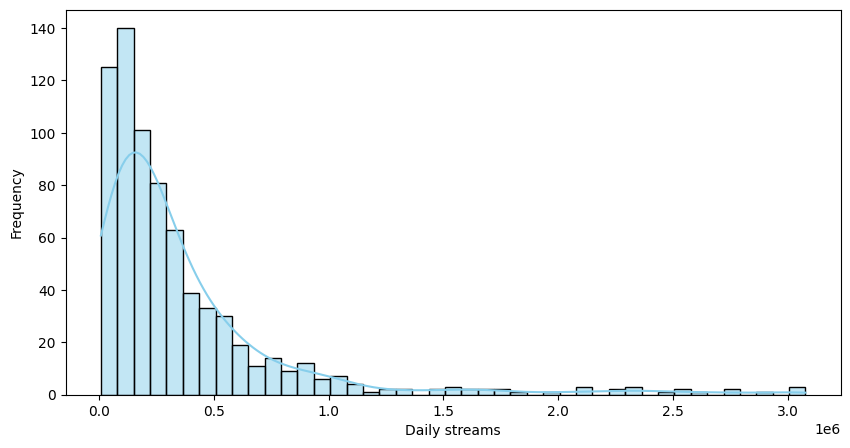

/tmp/ipykernel_3592/3546238069.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_collaboration',data=df,palette='Set2')


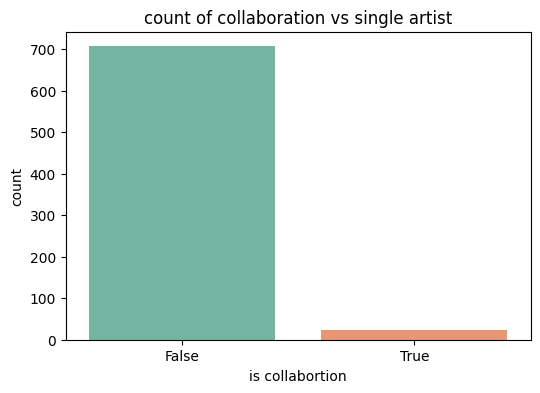

In [ ]:
#visulize distribution for key numeric features 
plt.figure(figsize=(10,5))
sns.histplot(df['daily_streams'],kde=True, color='skyblue')
plt.xlabel('Daily streams')
plt.ylabel('Frequency')
plt.show()

#count plot for collaborations
plt.figure(figsize=(6,4))
sns.countplot(x='is_collaboration',data=df,palette='Set2')
plt.title('count of collaboration vs single artist')
plt.xlabel('is collabortion')
plt.ylabel('count')
plt.show()

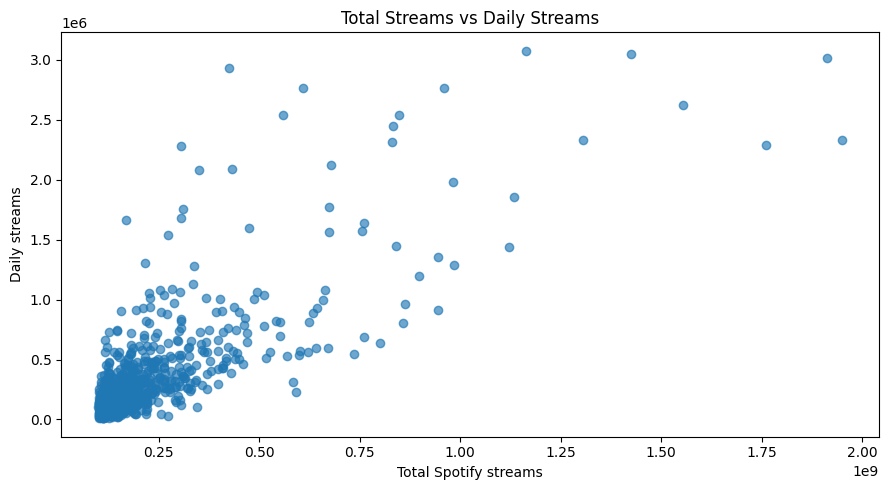

In [7]:
plt.figure(figsize=(9, 5))
plt.scatter(df["spotify_streams_total"], df["daily_streams"], alpha=0.65)
plt.xlabel("Total Spotify streams")
plt.ylabel("Daily streams")
plt.title("Total Streams vs Daily Streams")
plt.tight_layout()
plt.show()

## **4.Data Cleaning and Prepration**

In [16]:
#convert boolean column 'is_collaboration' to integer for modeling
df['is_collaboration']=df['is_collaboration'].astype(int)

**Preventing leakage :**

the following columns are **not** used:
- daily_streams_rank -directly derived from daily streams 

In [17]:
features = [
    "spotify_streams_total",
    "billed_artist_count",
    "is_collaboration"
]
target = "daily_streams"

X = df[features].copy()
y = df[target].copy()

print("Features:", features)
print("Target:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['spotify_streams_total', 'billed_artist_count', 'is_collaboration']
Target: daily_streams
X shape: (730, 3)
y shape: (730,)


In [19]:
x_train,x_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.20,
    random_state=42
)

print(f"Training rows:{len(x_train)}")
print(f"test rows: {len(x_test)}")

Training rows:584
test rows: 146


#  **5 Training model and comparing**

## Baseline

The baseline predicts the median daily streams for every test row. A useful model should clearly outperform it.

In [24]:
baseline = DummyRegressor(strategy="median")
baseline.fit(x_train, y_train)
baseline_pred = baseline.predict(x_test)

print(f"Baseline MAE : {mean_absolute_error(y_test, baseline_pred):,.0f}")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):,.0f}")
print(f"Baseline R²  : {r2_score(y_test, baseline_pred):.4f}")

Baseline MAE : 238,679
Baseline RMSE: 402,560
Baseline R²  : -0.1112


In [ ]:
def make_model(estimator):
    pipe=Pipeline([
        ("imputer",SimpleImputer(strategy="median"))
    ])